In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, time, timedelta
from SynthSpread.spreadviewer_class import SpreadSingle, SpreadViewerData, norm_coeff
from Database.TPData import TPData, TPDataDa, TPDataAssembly
from Strategies.MultipleMarketsIntensity_class import MultiTradeIntensity as TI

from Strategies.LeadLag_strategy.backtest_class import BacktestLL
from Strategies.LeadLag_strategy.strategy_class import StrategyLL, VolumeClass
tol=(1e-1)/2

In [114]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [115]:
max_secs_between_trades=45
cluster_trade_num_threshold=13
min_price_movement=0.1

take_profit=2
stop_loss=-2

br_fee = 0.0175
trail_sl_bool=True
trailing_tp_tau=10

# Test part - Nov, Dec (here it was calibrated)

## Data preparation

In [116]:
data_lead = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_test_short.csv',
                    parse_dates=['datetime']).reset_index()

data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_test_short.csv',
                    parse_dates=['datetime']).reset_index()

In [117]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [118]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [119]:
data_lag=data_lag.drop(index=177223).reset_index()
del data_lag['level_0']

In [120]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
0,1485,2023-11-01 09:00:01,NaN,NaN,114.66,115.21,114.935,1,44.0
1,1486,2023-11-01 09:00:02,NaN,NaN,114.66,115.20,114.930,1,1.0
2,1487,2023-11-01 09:00:05,NaN,NaN,114.65,115.14,114.895,1,3.0
3,1488,2023-11-01 09:00:10,NaN,NaN,114.51,115.14,114.825,1,5.0
4,1489,2023-11-01 09:00:11,NaN,NaN,114.51,115.13,114.820,1,1.0


In [121]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
438,438,2023-11-01 09:00:04.603000000,NaN,NaN,96.45,96.75,96.600,1
439,439,2023-11-01 09:00:08.017724752,96.45,2.0,96.45,96.75,96.600,0
440,440,2023-11-01 09:00:08.017784357,96.45,3.0,96.45,96.75,96.600,0
441,441,2023-11-01 09:00:17.908000000,NaN,NaN,96.25,96.44,96.345,1
442,442,2023-11-01 09:00:33.652000000,NaN,NaN,96.25,96.42,96.335,1


## Parameters and calculations

In [122]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee
param_dict['trail_sl_bool']=trail_sl_bool
param_dict['trailing_tp_tau']=trailing_tp_tau

param_dict['br_fee'] = 0.0175

param_dict['max_secs_between_trades'] = max_secs_between_trades
param_dict['cluster_trade_num_threshold'] = cluster_trade_num_threshold
param_dict['min_price_movement'] = min_price_movement

vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in strategy_class.stats_dict.keys() if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [123]:
from bokeh.plotting import figure, show, output_file
from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
import pandas as pd

# Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context

# Convert 'timestamp' to datetime if not already
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Assign color based on 'position' value
df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})

# Create ColumnDataSources
source_df = ColumnDataSource(df)
source_lead = ColumnDataSource(data_lead)
source_lag = ColumnDataSource(data_lag)

# Create a figure with dynamic sizing
p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# Adjust y-axes ranges
p.extra_y_ranges = {
   "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
   "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
}

# Add left and right y-axes
p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# Plotting with hover tools
lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# Define hover tools for each glyph
hover_position = HoverTool(renderers=[position_circles], tooltips=[
    ("Timestamp", "@timestamp{%F %T}"),
    ("Price Level", "@price_level"),
    ("Position", "@position"),
    ("Color", "@color"),
], formatters={'@timestamp': 'datetime'})

hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
    ("Datetime", "@datetime{%F %T}"),
    ("Lead Price", "@trd_price"),
], formatters={'@datetime': 'datetime'})

hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
    ("Datetime", "@datetime{%F %T}"),
    ("Lag Price", "@trd_price"),
], formatters={'@datetime': 'datetime'})

# Add hover tools to the plot
p.add_tools(hover_position, hover_lead, hover_lag)

# Customize plot
p.legend.location = "top_left"
p.xaxis.axis_label = "Datetime"
p.yaxis.axis_label = "Price Level"

# Show the plot
show(p)

<Axes: >

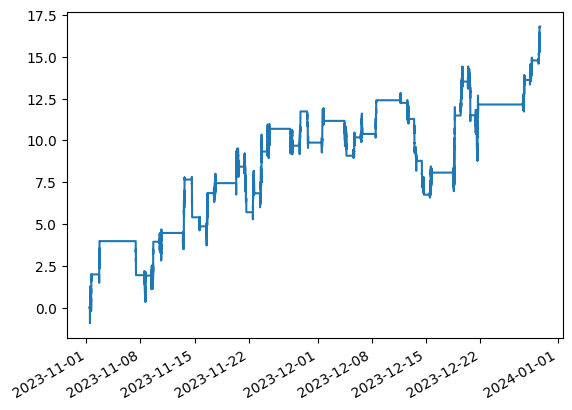

In [124]:
xx.plot()

In [125]:
#df[0:50]

In [126]:
xx[-1:]

2023-12-29 17:57:02    16.815
dtype: float64

# OOT part - Jan, Feb 

## Data preparation

In [127]:
data_lead = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lead_oot_short.csv',
                    parse_dates=['datetime']).reset_index()

data_lag = pd.read_csv(r's:\Algo\Files\andrej\Data\int_data_lag_dem2_oot_short.csv',
                    parse_dates=['datetime']).reset_index()

In [128]:
data_lag['time_diff']=data_lag['datetime'].diff().dt.total_seconds().fillna(0)

In [129]:
data_lead=data_lead[data_lead['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]
data_lag=data_lag[data_lag['datetime'].apply(lambda x: x.hour>8 and  x.hour<18)]

In [130]:
data_lag=data_lag.drop(index=177223).reset_index()
del data_lag['level_0']

In [131]:
data_lag.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side,time_diff
0,17,2024-01-02 09:00:26,NaN,NaN,83.25,86.37,84.810,1,269.0
1,18,2024-01-02 09:00:30,NaN,NaN,83.25,86.25,84.750,1,4.0
2,19,2024-01-02 09:01:32,NaN,NaN,83.25,86.00,84.625,1,62.0
3,20,2024-01-02 09:09:57,NaN,NaN,83.25,85.99,84.620,1,505.0
4,21,2024-01-02 09:11:07,NaN,NaN,83.00,85.99,84.495,1,70.0


In [132]:
data_lead.head()

,index,datetime,trd_price,volume,bid_price,ask_price,mid_price,trd_side
150,150,2024-01-02 09:00:00.907744884,91.97,2.0,91.97,92.50,92.235,0
151,151,2024-01-02 09:00:02.000000000,NaN,NaN,91.96,92.50,92.230,1
152,152,2024-01-02 09:00:30.000000000,NaN,NaN,91.96,92.49,92.225,1
153,153,2024-01-02 09:00:40.962116718,92.00,3.0,91.96,92.49,92.225,0
154,154,2024-01-02 09:00:41.104269743,91.97,1.0,91.96,92.49,92.225,0


## Parameters and calculations

In [133]:
instr = 'm2'

contr_vars = []

param_list = ['t_end', 'take_profit', 'stop_loss']
param_dict = {k: [] for k in param_list}
param_dict['t_end'] = time(17)
param_dict['take_profit'] = take_profit
param_dict['stop_loss'] = stop_loss
param_dict['ba_max']=0.3

param_dict['br_fee'] = br_fee
param_dict['trail_sl_bool']=trail_sl_bool
param_dict['trailing_tp_tau']=trailing_tp_tau

param_dict['max_secs_between_trades'] = max_secs_between_trades
param_dict['cluster_trade_num_threshold'] = cluster_trade_num_threshold
param_dict['min_price_movement'] = min_price_movement

vol_class = VolumeClass(1, {'max_clips': 1})
backtest_class = BacktestLL(vol_class)
# model_class = HawkesIntensity
strategy_class = StrategyLL(
                            strategy='LL',
                            market='de',
                            instrument=instr, 
                            is_overnight=False)

strategy_class.load_params(param_dict, contr_vars)

xx = backtest_class.simulate_strategy(strategy_class, instr, data_lag, data_lead)

df = pd.DataFrame({k: strategy_class.stats_dict[k] for k in strategy_class.stats_dict.keys() if k in ['timestamp', 'position', 'price_level']})
df = pd.concat([df, ])

## Results

In [134]:
from bokeh.plotting import figure, show, output_file
from bokeh.models import ColumnDataSource, Range1d, LinearAxis, HoverTool
import pandas as pd

# Assuming 'data_lag', 'data_lead', and 'df' are already defined as per your context

# Convert 'timestamp' to datetime if not already
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Assign color based on 'position' value
df['color'] = df['position'].map({1: 'green', -1: 'red', 0: 'black'})

# Create ColumnDataSources
source_df = ColumnDataSource(df)
source_lead = ColumnDataSource(data_lead)
source_lag = ColumnDataSource(data_lag)

# Create a figure with dynamic sizing
p = figure(x_axis_type="datetime", title="Strategy Positions", sizing_mode='stretch_both')

# Adjust y-axes ranges
p.extra_y_ranges = {
   "Lead price": Range1d(start=data_lead['trd_price'].min(), end=data_lead['trd_price'].max()),
   "Lag price": Range1d(start=data_lag['trd_price'].min(), end=data_lag['trd_price'].max())
}

# Add left and right y-axes
p.add_layout(LinearAxis(y_range_name="Lead price", axis_label="Lead Price"), 'left')
p.add_layout(LinearAxis(y_range_name="Lag price", axis_label="Lag Price"), 'right')

# Plotting with hover tools
lead_crosses = p.cross(x='datetime', y='trd_price', source=source_lead, size=10, color='blue', legend_label="Lead Price", y_range_name="Lead price")
lag_crosses = p.cross(x='datetime', y='trd_price', source=source_lag, size=10, color='orange', legend_label="Lag Price", y_range_name="Lag price")
position_circles = p.circle(x='timestamp', y='price_level', source=source_df, size=10, color='color', legend_label="Position", y_range_name="Lag price")

# Define hover tools for each glyph
hover_position = HoverTool(renderers=[position_circles], tooltips=[
    ("Timestamp", "@timestamp{%F %T}"),
    ("Price Level", "@price_level"),
    ("Position", "@position"),
    ("Color", "@color"),
], formatters={'@timestamp': 'datetime'})

hover_lead = HoverTool(renderers=[lead_crosses], tooltips=[
    ("Datetime", "@datetime{%F %T}"),
    ("Lead Price", "@trd_price"),
], formatters={'@datetime': 'datetime'})

hover_lag = HoverTool(renderers=[lag_crosses], tooltips=[
    ("Datetime", "@datetime{%F %T}"),
    ("Lag Price", "@trd_price"),
], formatters={'@datetime': 'datetime'})

# Add hover tools to the plot
p.add_tools(hover_position, hover_lead, hover_lag)

# Customize plot
p.legend.location = "top_left"
p.xaxis.axis_label = "Datetime"
p.yaxis.axis_label = "Price Level"

# Show the plot
show(p)

<Axes: >

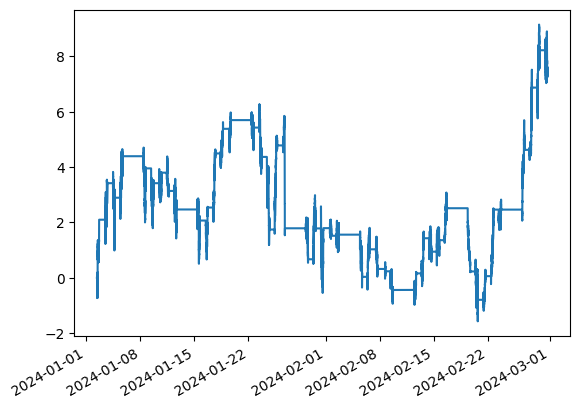

In [135]:
xx.plot()

In [136]:
#df[0:50]

In [137]:
xx[-1:]

2024-02-29 17:59:55    7.345
dtype: float64